# 2D (and 3D) Heat Diffusion Simulation

A numerical simulation of the heat equation

$$\frac{\partial T}{\partial t} = \alpha \nabla^2 T$$

using an explicit finite-difference method: the Laplacian $\nabla^2 T$ is approximated at each grid
cell with a 5-point stencil (7-point in 3D) over its immediate neighbors, and the temperature is
advanced forward in time step by step (explicit Euler). Includes a hot square diffusing outward, a
constant-temperature wall, an empirical demonstration of the CFL stability limit, and an extension to
3D.

## Setting Up the Grid

A 50×50 grid, starting at 0 everywhere except a 5×5 hot spot in the center, set to 100.

In [1]:
import numpy as np

grid_size = 50
grid = np.zeros((grid_size, grid_size))

hot_spot = (int(grid_size / 2), int(grid_size / 2))
center_row, center_col = hot_spot
grid[center_row - 2: center_row + 3, center_col - 2: center_col + 3] = 100.0

print(grid[23:28, 23:28])


[[100. 100. 100. 100. 100.]
 [100. 100. 100. 100. 100.]
 [100. 100. 100. 100. 100.]
 [100. 100. 100. 100. 100.]
 [100. 100. 100. 100. 100.]]


## The Diffusion Step

At each interior cell, the discrete Laplacian is the sum of the four neighbors minus four times the
center value. One explicit Euler step then updates every interior cell by
$T \leftarrow T + \alpha \, \Delta t \, \nabla^2 T$.

In [2]:
north = grid[:-2, 1:-1]
south = grid[2:, 1:-1]
east = grid[1:-1, 2:]
west = grid[1:-1, :-2]
center = grid[1:-1, 1:-1]

laplacian = north + south + east + west - 4 * center


### Boundary Conditions

The four edges of the grid are never updated by `diffusion_step` — only the interior
(`grid[1:-1, 1:-1]`) changes each step. That makes this a fixed-temperature (Dirichlet) boundary: each
edge cell is held permanently at whatever value it started with. Since the grid starts at 0 everywhere
except the hot spot, the edges act as a constant 0° boundary that the heat diffuses into and is
absorbed by.

In [3]:
alpha = 0.2
dt = 1.0


def diffusion_step(grid, alpha, dt):
    north = grid[:-2, 1:-1]
    south = grid[2:, 1:-1]
    east = grid[1:-1, 2:]
    west = grid[1:-1, :-2]
    center = grid[1:-1, 1:-1]

    laplacian = north + south + east + west - 4 * center

    new_grid = grid.copy()
    new_grid[1:-1, 1:-1] = center + alpha * dt * laplacian

    return new_grid


### Single-Step Sanity Check

In [4]:
new_grid = diffusion_step(grid, alpha, dt)
print(grid[25, 25], new_grid[25, 25])  # center of hot spot — should decrease slightly
print(grid[20, 20], new_grid[20, 20])  # just outside hot spot — should increase slightly (or stay near 0, depending on distance)


100.0 100.0
0.0 0.0


## Simulating Many Steps

In [5]:
num_steps = 200
current_grid = grid.copy()

for step in range(num_steps):
    current_grid = diffusion_step(current_grid, alpha, dt)

print(grid[25, 25], current_grid[25, 25])
print(grid[20, 20], current_grid[20, 20])


100.0 4.842674063625528
0.0 3.5738827880296777


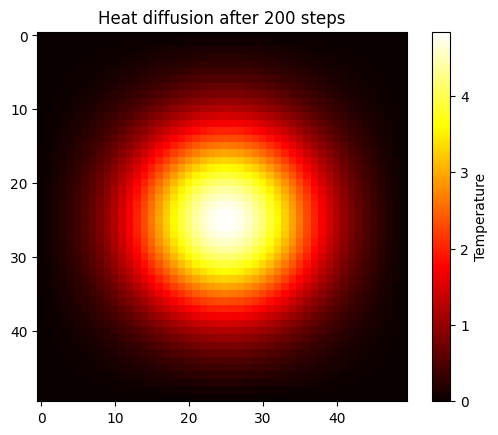

In [6]:
import matplotlib.pyplot as plt

plt.imshow(current_grid, cmap="hot")
plt.colorbar(label="Temperature")
plt.title(f"Heat diffusion after {num_steps} steps")
plt.show()


## Animating the Diffusion

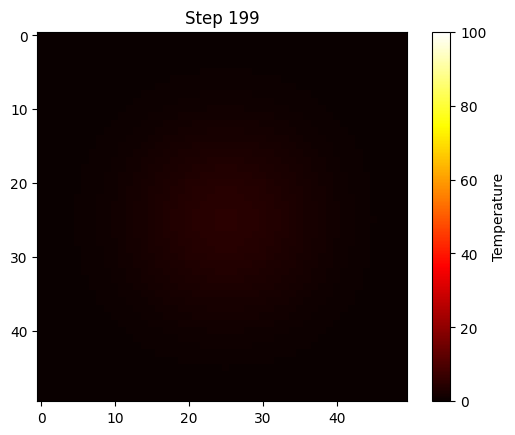

In [7]:
import matplotlib.animation as animation

fig, ax = plt.subplots()
im = ax.imshow(grid, cmap="hot", vmin=0, vmax=100)
plt.colorbar(im, label="Temperature")

current_grid = [grid.copy()]  # wrapped in a list so update() can mutate it


def update(frame):
    current_grid[0] = diffusion_step(current_grid[0], alpha, dt)
    im.set_data(current_grid[0])
    ax.set_title(f"Step {frame}")
    return [im]


ani = animation.FuncAnimation(fig, update, frames=200, interval=30, blit=True)
ani.save("heat_diffusion.gif", writer="pillow", fps=30)


## A Different Initial Condition: Heated Wall

Instead of a hot spot, the entire left column starts at 100° — a constant heat source along one wall.

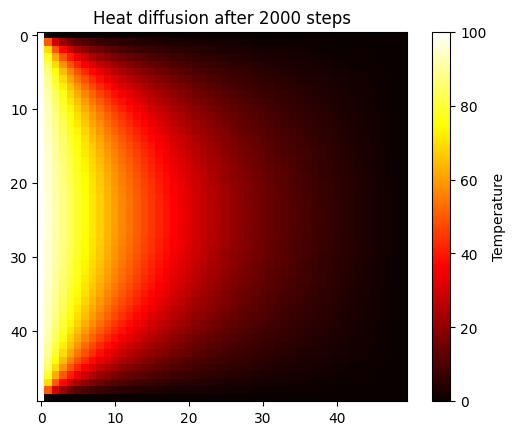

In [8]:
grid_size = 50
grid1 = np.zeros((grid_size, grid_size))
grid1[:, :1] = 100.0
num_steps = 2000
current_grid = grid1.copy()

for step in range(num_steps):
    current_grid = diffusion_step(current_grid, alpha, dt)

plt.imshow(current_grid, cmap="hot")
plt.colorbar(label="Temperature")
plt.title(f"Heat diffusion after {num_steps} steps")
plt.show()


## The CFL Stability Limit

Explicit finite-difference schemes like this one are only numerically stable if the time step is small
enough relative to the diffusion rate and grid spacing — this is the
[Courant–Friedrichs–Lewy (CFL) condition](https://en.wikipedia.org/wiki/Courant%E2%80%93Friedrichs%E2%80%93Lewy_condition).
For this 2D 5-point stencil (with unit grid spacing), the theoretical bound is $\alpha \, \Delta t \le 0.25$.
Below, we verify this empirically: violating the bound causes the simulation to diverge into an
unphysical checkerboard pattern, while respecting it keeps the simulation stable.

### Violating the Limit

In [9]:
alpha = 0.2
dt = 5.0  # way too large — alpha*dt = 1.0, far past the 0.25 stability limit
num_unstable_steps = 20

test_grid = grid.copy()
for step in range(num_unstable_steps):
    test_grid = diffusion_step(test_grid, alpha, dt)

print(test_grid[25, 25])
print(test_grid.min(), test_grid.max())


7.34054158980073e+16
-7.51584534719642e+16 7.523779673217229e+16


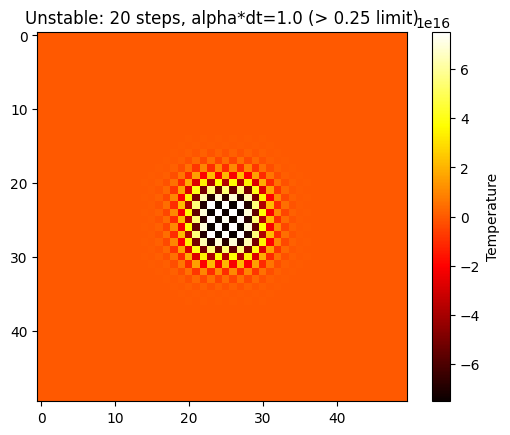

In [10]:
plt.imshow(test_grid, cmap="hot")
plt.colorbar(label="Temperature")
plt.title(f"Unstable: {num_unstable_steps} steps, alpha*dt=1.0 (> 0.25 limit)")
plt.show()


### Respecting the Limit

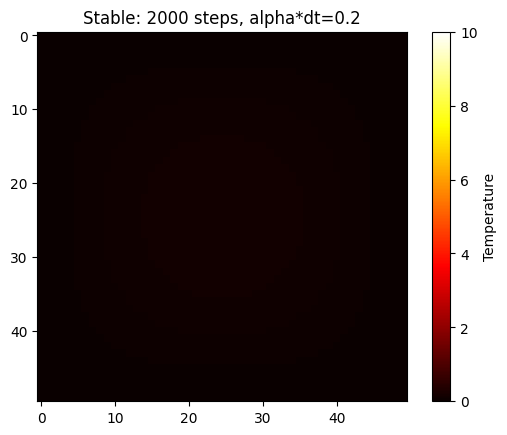

In [11]:
alpha = 0.2
dt = 1.0  # alpha*dt = 0.2, safely under the 0.25 limit
test_grid_stable = grid.copy()
for step in range(2000):
    test_grid_stable = diffusion_step(test_grid_stable, alpha, dt)

plt.imshow(test_grid_stable, cmap="hot", vmin=0, vmax=10)
plt.colorbar(label="Temperature")
plt.title("Stable: 2000 steps, alpha*dt=0.2")
plt.show()


## Extending to 3D

The same explicit finite-difference scheme generalizes directly to 3D: the Laplacian stencil now sums
6 face-adjacent neighbors instead of 4, minus six times the center value.

### Setup

In [12]:
grid_size_3d = 20
grid_3d = np.zeros((grid_size_3d, grid_size_3d, grid_size_3d))

center = grid_size_3d // 2
grid_3d[center - 2:center + 3, center - 2:center + 3, center - 2:center + 3] = 100.0


### The 3D Diffusion Step

In [13]:
alpha = 0.2
dt = 1.0


def diffusion_step_3d(grid, alpha, dt):
    up = grid[:-2, 1:-1, 1:-1]
    down = grid[2:, 1:-1, 1:-1]
    north = grid[1:-1, :-2, 1:-1]
    south = grid[1:-1, 2:, 1:-1]
    east = grid[1:-1, 1:-1, 2:]
    west = grid[1:-1, 1:-1, :-2]
    center = grid[1:-1, 1:-1, 1:-1]

    laplacian = up + down + north + south + east + west - 6 * center

    new_grid = grid.copy()
    new_grid[1:-1, 1:-1, 1:-1] = center + alpha * dt * laplacian

    return new_grid


### Sanity Check

In [14]:
new_grid_3d = diffusion_step_3d(grid_3d, alpha, dt)
print("center:", grid_3d[10, 10, 10], "->", new_grid_3d[10, 10, 10])
print("just outside block:", grid_3d[7, 10, 10], "->", new_grid_3d[7, 10, 10])


center: 100.0 -> 100.0
just outside block: 0.0 -> 20.0


### Visualizing a 2D Slice

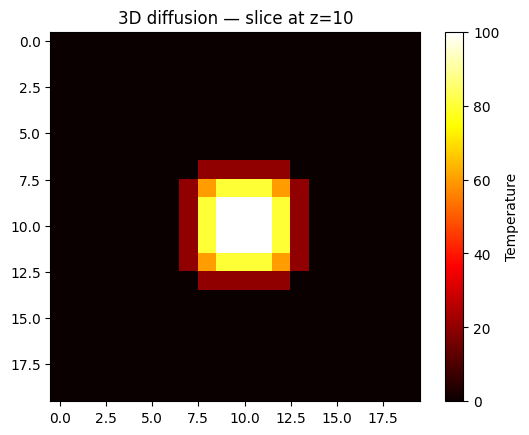

In [15]:
mid = grid_size_3d // 2
plt.imshow(new_grid_3d[mid, :, :], cmap="hot", vmin=0, vmax=100)
plt.colorbar(label="Temperature")
plt.title(f"3D diffusion — slice at z={mid}")
plt.show()


### Visualizing in 3D

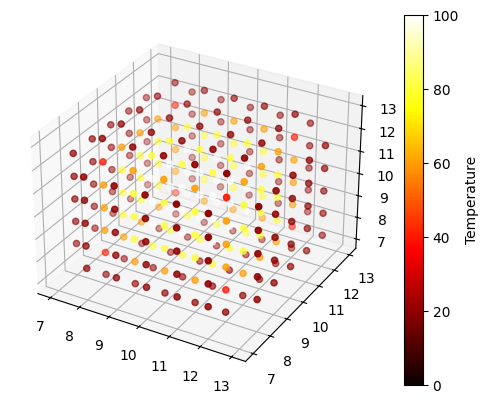

In [16]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x, y, z = np.indices(new_grid_3d.shape)
values = new_grid_3d.flatten()

mask = values > 5  # only show cells with meaningful heat
sc = ax.scatter(x.flatten()[mask], y.flatten()[mask], z.flatten()[mask],
                 c=values[mask], cmap="hot", vmin=0, vmax=100)
plt.colorbar(sc, label="Temperature")
plt.show()
